In [72]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import classification_report, accuracy_score

In [73]:
#1.Load the dataset
print("Loading the dataset...")
df = pd.read_csv("credit_risk_dataset.csv")

Loading the dataset...


In [74]:
#Quick inspection
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                

In [75]:
2.#Basic Preprocessing
#Fill missing numeric values with column median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [76]:
# Set target explicitly to loan_status
target_col = 'loan_status'

x = df.drop(columns=['loan_status'])
y = df['loan_status']

In [77]:
#Connvert target labels to 0 and 1 if they are text (e.g., 'good'/'bad')
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

In [78]:
#One-hot encode categorical features
x = pd.get_dummies(x, drop_first=True)

In [79]:
#3.Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [80]:
#4.Feature Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [81]:
#5.Model Training (Random Forest)
print("\nTraining the Random Forest Model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train_scaled, y_train)


Training the Random Forest Model...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
#6.Model Evaluation
y_pred = model.predict(x_test_scaled)
y_proba = model.predict_proba(x_test_scaled)[:, 1]

print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517

Accuracy Score: 0.9319
ROC-AUC Score: 0.9314


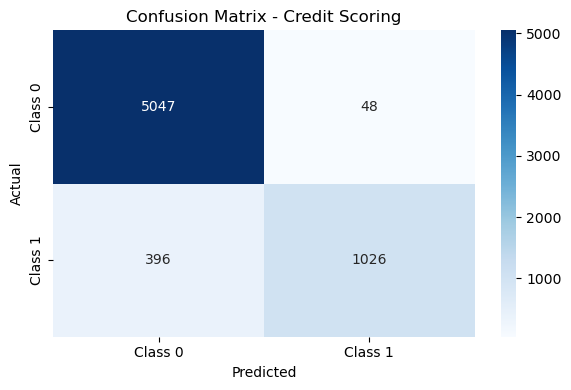

In [86]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred), 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)
plt.title('Confusion Matrix - Credit Scoring')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()